# ch07 연속형 확률변수

- 1차원 연속형 확률변수

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [2]:
from scipy import integrate
import warnings

# 적분에 관한 warning을 출력하지 않도록 한다
warnings.filterwarnings('ignore',
                        category=integrate.IntegrationWarning)

In [3]:
x_range = np.array([0,1,2,3])

In [4]:
def f(x):
    if x_range[0] <= x < x_range[1]:
        return x
    elif x_range[1] <= x < x_range[2]:
        return 1
    elif x_range[2] <= x <= x_range[3]:
        return 3-x
    else:
        return 0

In [5]:
X = [x_range, f]

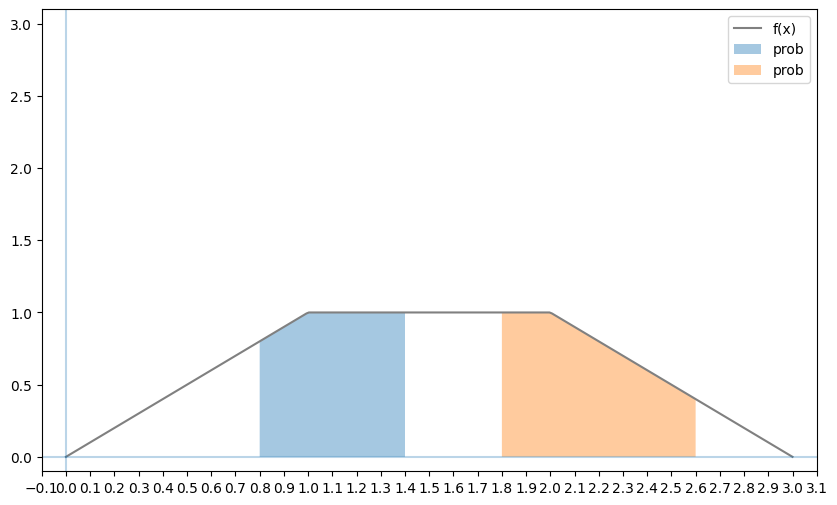

In [6]:
xs = np.linspace(x_range[0], x_range[3], 300)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [f(x) for x in xs], label='f(x)', color='gray')
ax.hlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(0, -0.1, 3.1, alpha=0.3)
# ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

xs = np.linspace(0.8, 1.4, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob', alpha = 0.4)
xs = np.linspace(1.8, 2.6, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob', alpha = 0.4)

ax.set_xticks(np.arange(-0.1, 3.2, 0.1))
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.1, 3.1)
ax.legend()

plt.show()

In [7]:
integrate.quad(f, 0.8, 1.4)

(0.580, 0.000)

In [8]:
integrate.quad(f, 1.8, 2.6)

(0.620, 0.000)

In [9]:
from scipy.optimize import minimize_scalar

res = minimize_scalar(f)
# 함수의 최솟값은 fun이라는 인스턴스 변수에
res.fun

np.int64(0)

In [10]:
integrate.quad(f, -np.inf, np.inf)[0]

2.000

In [11]:
def fnew(x):
    return f(x) * 0.5

In [12]:
def F(x):
    return integrate.quad(fnew, -np.inf, x)[0]

In [13]:
F(2.6) - F(1.8)

0.310

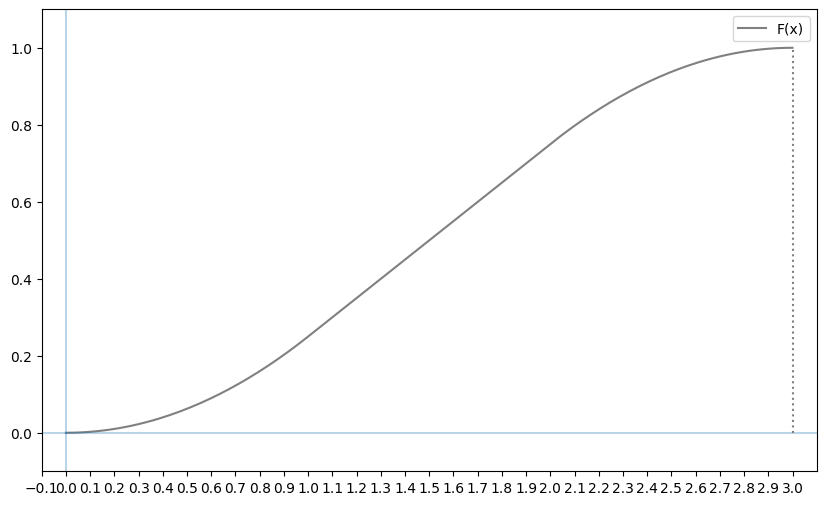

In [14]:
xs = np.linspace(x_range[0], x_range[3], 300)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [F(x) for x in xs], label='F(x)', color='gray')
ax.hlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.1, 3.1, 0.1))
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()

##### 연습문제

코드로 구현하여 문제를 풀어주세요
- k 값
- 기댓값
- 분산
- F(x) 그래프
- Y = -2X+5 선형변환
- 5번의 기댓값, 분산
- 그래프 비교

In [227]:
x_range = np.array([0,1,2,3,4])

In [228]:
#1번
k = 0.5
def fx(x):
    if x_range[0] <= x < x_range[1]:
        return k * x
    elif x_range[1] <= x < x_range[2]:
        return k * (2-x)
    elif x_range[2] <= x <= x_range[3]:
        return k * (x-2)
    elif x_range[3] <= x <= x_range[4]:
        return k * (4-x)
    else:
        return 0
    
print("k의 값은 " + str(k) + "이다.")

k의 값은 0.5이다.


In [229]:
X = [x_range, fx]

In [230]:
integrate.quad(fx, -np.inf, np.inf)[0]

1.000

In [231]:
#2번
def E(X, g = lambda x: x):
    x_range, f = X
    def integrand(x):
        return x * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

E(X)

2.000

In [232]:
#3번
def V(X, g = lambda x: x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (x - mean) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

V(X)

1.167

In [233]:
#4번
def Fx(x):
    return integrate.quad(fx, -np.inf, x)[0]

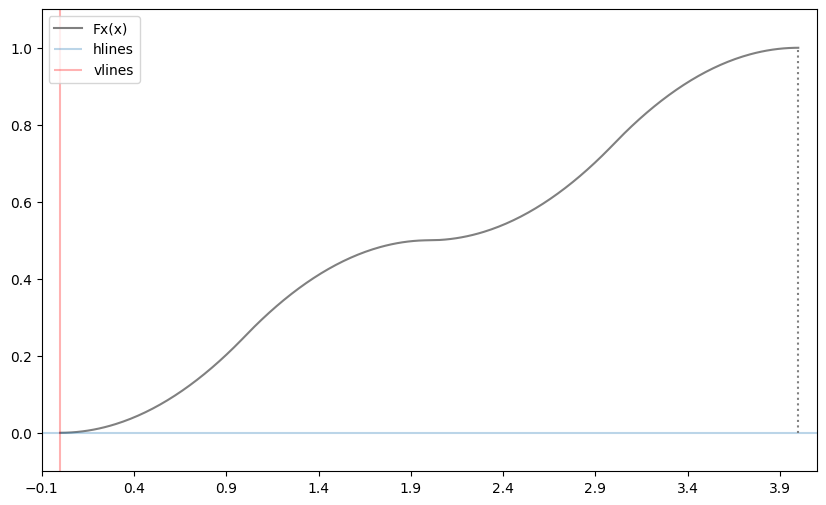

In [234]:
xs = np.linspace(x_range[0], x_range[4], 400)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [Fx(x) for x in xs], label='Fx(x)', color='gray')
ax.hlines(0, -0.1, 4.1, alpha=0.3, label = 'hlines')
ax.vlines(0, -0.1, 4.1, alpha=0.3, label = 'vlines', colors = 'red')
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.1, 4.1, 0.5))
ax.set_xlim(-0.1, 4.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()

In [235]:
#5번
y_range = np.array([5, 3])

def g(y):
    if y_range[1] <= y <= y_range[0]:
        return (y - 5) / (-2) * k
    else:
        return 0
    
def G(y):
    return integrate.quad(g, y_range[1], y)[0]

In [237]:
E_Y = E(X, g=lambda x: -2*x + 5)
E_Ys2 = E(X, g=lambda x: (-2*x + 5)**2)
V_Y = E_Ys2 - E_Y**2

In [238]:
#6번
print(f"Y의 기댓값: {E_Y:.3f}")
print(f"Y의 분산: {V_Y:.3f}")

Y의 기댓값: 2.000
Y의 분산: -2.000


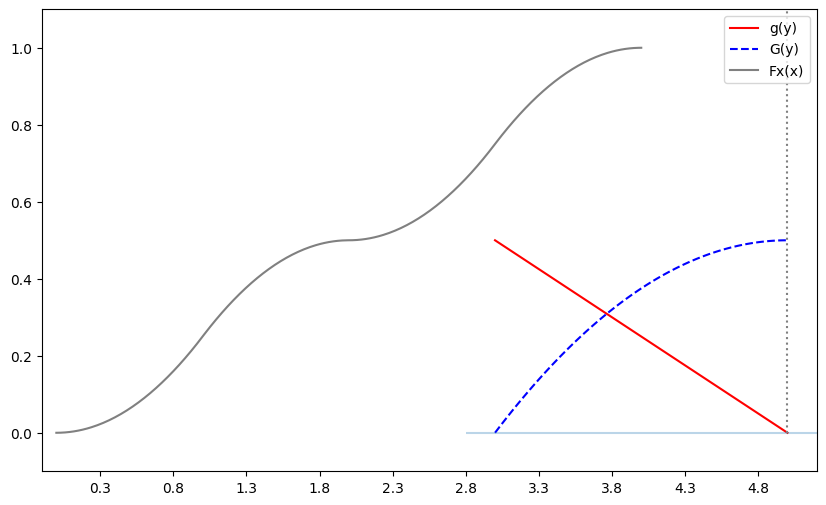

In [241]:
ys = np.linspace(y_range[1], y_range[0], 100)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(ys, [g(y) for y in ys],
        label='g(y)', color='red')
ax.plot(ys, [G(y) for y in ys],
        label='G(y)', ls='--', color='blue')
ax.plot(xs, [Fx(x) for x in xs], label='Fx(x)', color='gray')
ax.hlines(0, 2.8, 5.2, alpha=0.3)
ax.vlines(ys.max(), 0, 5, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.2, 5.2, 0.5))
ax.set_xlim(-0.1, 5.2)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()

- 2차원 연속형 확률변수

In [15]:
x_range = [0, 2]
y_range = [0, 1]

def f_xy(x, y):
    if 0 <= y <= 1 and 0 <= x - y <= 1:
        return 4 * y * (x - y)
    else:
        return 0
    
XY = [x_range, y_range, f_xy]

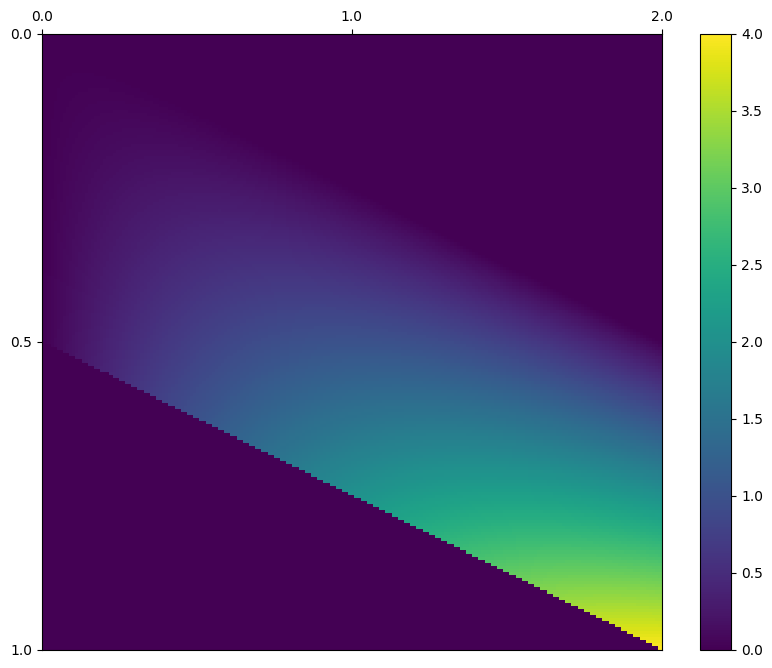

In [16]:
#결합확률밀도함수

s = np.linspace(x_range[0], x_range[1], 200)
ys = np.linspace(y_range[0], y_range[1], 200)
pd = np.array([[f_xy(x, y) for y in ys] for x in xs])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.pcolor(pd)
ax.set_xticks(np.linspace(0, 200, 3), minor=False)
ax.set_yticks(np.linspace(0, 200, 3), minor=False)
ax.set_xticklabels(np.linspace(0, 2, 3))
ax.set_yticklabels(np.linspace(0, 1, 3))
ax.invert_yaxis()
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)
plt.show()

In [17]:
# 첫 번째 인수는 피적분함수、두 번째 인수는 x의 적분구간과 y의 적분구간
integrate.nquad(f_xy,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

1.000

In [18]:
#주변확률밀도함수

from functools import partial

def f_X(x):
    return integrate.quad(partial(f_xy, x), -np.inf, np.inf)[0]
def f_Y(y):
    return integrate.quad(partial(f_xy, y=y), -np.inf, np.inf)[0]

X = [x_range, f_X]
Y = [y_range, f_Y]

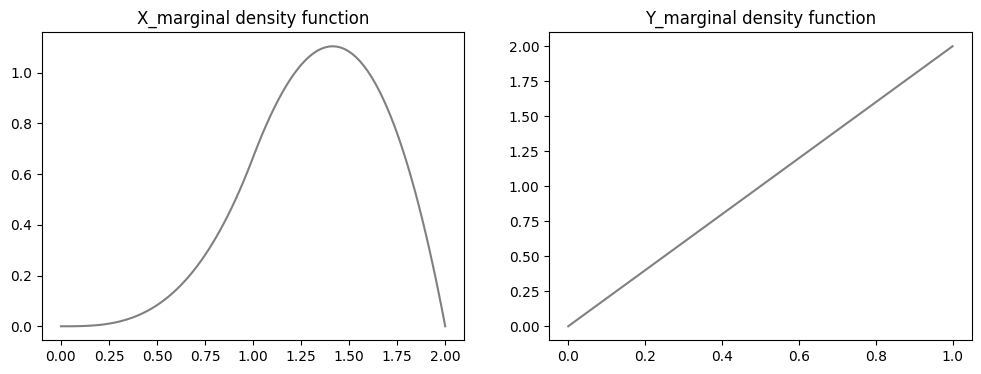

In [19]:
xs = np.linspace(*x_range, 100)
ys = np.linspace(*y_range, 100)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.plot(xs, [f_X(x) for x in xs], color='gray')
ax2.plot(ys, [f_Y(y) for y in ys], color='gray')
ax1.set_title('X_marginal density function')
ax2.set_title('Y_marginal density function')

plt.show()

In [20]:
#기댓값 E(X)

def integrand(x, y):
    return x * f_xy(x, y)

integrate.nquad(integrand,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

1.333

In [21]:
def E(XY, g):
    x_range, y_range, f_xy = XY
    def integrand(x, y):
        return g(x, y) * f_xy(x, y)
    
    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

X와 Y의 기댓값

In [22]:
mean_X = E(XY, lambda x, y: x)
mean_X

1.333

In [23]:
mean_Y = E(XY, lambda x, y: y)
mean_Y

0.667

기댓값의 선형성

In [24]:
a, b = 2, 3

E(XY, lambda x, y: a*x + b*y)

4.667

In [25]:
a * mean_X + b * mean_Y

4.667

In [26]:
#분산

def integrand(x, y):
    return (x - mean_X)**2 * f_xy(x, y)

integrate.nquad(integrand,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

0.111

In [27]:
def V(XY, g):
    x_range, y_range, f_xy = XY
    mean = E(XY, g)
    def integrand(x, y):
        return (g(x, y) - mean)**2 * f_xy(x, y)

    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

X와 Y의 분산

In [28]:
var_X = V(XY, lambda x, y: x)
var_X

0.111

In [29]:
var_Y = V(XY, lambda x, y: y)
var_Y

0.056

In [31]:
#공분산

def Cov(XY):
    x_range, y_range, f_xy = XY
    mean_X = E(XY, lambda x, y: x)
    mean_Y = E(XY, lambda x, y: y)
    def integrand(x, y):
        return (x-mean_X) * (y-mean_Y) * f_xy(x, y)

    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

cov_xy = Cov(XY)
cov_xy

0.056

분산과 공분산

In [32]:
V(XY, lambda x, y: a*x + b*y)

1.611

In [33]:
a**2 * var_X + b**2 * var_Y + 2*a*b * cov_xy

1.611

In [34]:
#상관계수

cov_xy / np.sqrt(var_X * var_Y)

0.707

##### 연습문제

코드로 구현하여 문제를 풀어주세요
- k 값
- P(X < 1.5, Y > 0.4)
- 주변밀도함수 fX(x), fY(y) 구하고 그래프
- E[X]. E[Y], V(X), V(Y), Cov(X, Y), 상관계수 raw 구하기
- 선형변환 : Z = X - 2Y 
- 5번의 E[Z], V(Z)
- E[Z] = E[X] - 2E[Y], V(Z) = V(X) + 4V(Y) -4Cov(X, Y) 비교

In [61]:
x_range = [0, 2]
y_range = [0, 1]

#1번
k = 0.5

def f_XY(x, y):
    if 0 <= y <= 1 and 0 <= x <= 1:
        return k * (x + y)
    elif 0 <= y <= 1 and 1 <= x <= 2:
        return k * (2 - x + y)
    else:
        return 0
    
XY = [x_range, y_range, f_XY]

print("k의 값은 " + str(k) + "이다.")

k의 값은 0.5이다.


In [62]:
# 그래프의 누적합(적분값)이 1이어야 함
integrate.nquad(f_XY,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

1.000

In [63]:
#2번
# 첫 번째 인수는 피적분함수、두 번째 인수는 x의 적분구간과 y의 적분구간
integrate.nquad(f_XY,
                [[-np.inf, 1.5],
                 [0.4, np.inf]])[0]

0.577

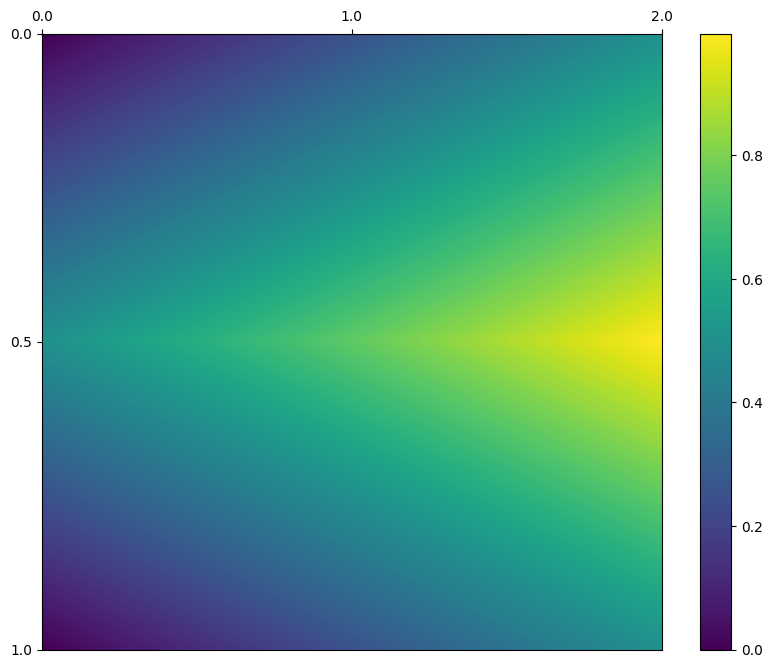

In [64]:
xs = np.linspace(x_range[0], x_range[1], 200)
ys = np.linspace(y_range[0], y_range[1], 200)
pd = np.array([[f_XY(x, y) for y in ys] for x in xs])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.pcolor(pd)
ax.set_xticks(np.linspace(0, 200, 3), minor=False)
ax.set_yticks(np.linspace(0, 200, 3), minor=False)
ax.set_xticklabels(np.linspace(0, 2, 3))
ax.set_yticklabels(np.linspace(0, 1, 3))
ax.invert_yaxis()
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)
plt.show()

In [65]:
from functools import partial

def f_X(x):
    return integrate.quad(partial(f_XY, x), -np.inf, np.inf)[0]
def f_Y(y):
    return integrate.quad(partial(f_XY, y=y), -np.inf, np.inf)[0]

X = [x_range, f_X]
Y = [y_range, f_Y]

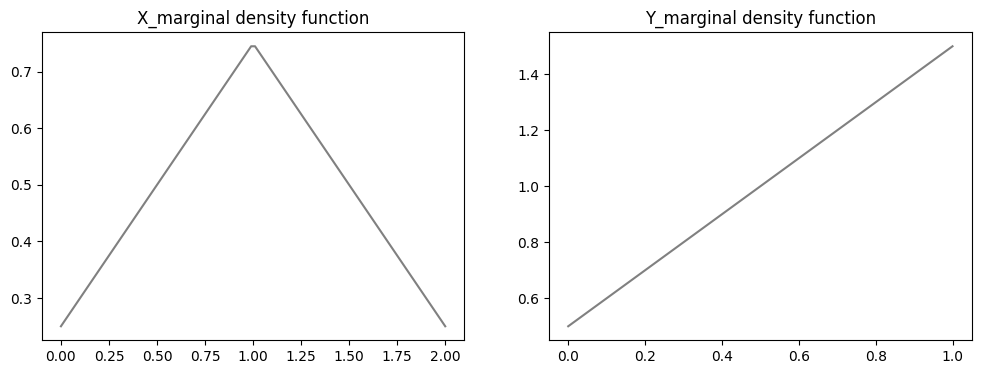

In [66]:
#3번
xs = np.linspace(*x_range, 100)
ys = np.linspace(*y_range, 100)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.plot(xs, [f_X(x) for x in xs], color='gray')
ax2.plot(ys, [f_Y(y) for y in ys], color='gray')
ax1.set_title('X_marginal density function')
ax2.set_title('Y_marginal density function')

plt.show()

In [67]:
def integrand(x, y):
    return x * f_XY(x, y)

integrate.nquad(integrand,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

1.000

In [68]:
def E(XY, g):
    x_range, y_range, f_XY = XY
    def integrand(x, y):
        return g(x, y) * f_XY(x, y)
    
    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

mean_X = E(XY, lambda x, y: x)
mean_Y = E(XY, lambda x, y: y)

print("E[X]: ", mean_X)
print("E[Y]: ", mean_Y)

a, b = 1, -2
print(E(XY, lambda x, y: a*x + b*y))

E[X]:  1.000000000000015
E[Y]:  0.5833333333334538
-0.1666666666666471


In [52]:
def integrand(x, y):
    return (x - mean_X)**2 * f_XY(x, y)

integrate.nquad(integrand,
                [[-np.inf, np.inf],
                 [-np.inf, np.inf]])[0]

0.222

In [56]:
def V(XY, g):
    x_range, y_range, f_XY = XY
    mean = E(XY, g)
    def integrand(x, y):
        return (g(x, y) - mean)**2 * f_XY(x, y)

    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

var_X = V(XY, lambda x, y: x)
var_Y = V(XY, lambda x, y: y)

print("V(X): ",var_X ,"\nV(Y): ", var_Y)

V(X):  0.2222193561565177 
V(Y):  0.07638290295823277


In [72]:
mean_Z = E(XY, lambda x, y:x - 2 * y)
print("E[Z]: ", mean_Z)

var_Z = V(XY, lambda x, y:x - 2 * y)
print("V(Z): ", var_Z)

E[Z]:  -0.1666666666666471
V(Z):  0.5555555555541447


In [73]:
def Cov(XY):
    x_range, y_range, f_XY = XY
    mean_X = E(XY, lambda x, y: x)
    mean_Y = E(XY, lambda x, y: y)
    def integrand(x, y):
        return (x-mean_X) * (y-mean_Y) * f_XY(x, y)

    return integrate.nquad(integrand,
                           [[-np.inf, np.inf],
                            [-np.inf, np.inf]])[0]

cov_xy = Cov(XY)
cov_xy

0.000

In [76]:
print("E[Z] = E[X] - 2E[Y] >> ", mean_Z, " = ", mean_X, " - ", 2 * mean_Y)
print("V(Z) = V(X) + 4V(Y) - 4Cov(X,Y) >> ", var_Z, " = ", var_X, " + ", 4 * var_Y, " - ", 4 * cov_xy)

E[Z] = E[X] - 2E[Y] >>  -0.1666666666666471  =  1.000000000000015  -  1.1666666666669077
V(Z) = V(X) + 4V(Y) - 4Cov(X,Y) >>  0.5555555555541447  =  0.2222193561565177  +  0.3055316118329311  -  1.0256367085236455e-14
